In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import to_categorical

from core.data import load_from_kaggle


c:\Users\yamen\Desktop\Weiterbildung\visual Studio Code\mein-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_link = "alfrandom/protein-secondary-structure" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw\protein-secondary-structure' already exists with files. Skipping download (replace=False).


In [3]:
files

['2018-06-06-pdb-intersect-pisces.csv', '2018-06-06-ss.cleaned.csv']

In [4]:
df = pd.read_csv('../data/raw/protein-secondary-structure/2018-06-06-ss.cleaned.csv')
df.head()

,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa
0,1A30,C,EDL,CBC,CEC,3,False
1,1B05,B,KCK,CBC,CEC,3,False
2,1B0H,B,KAK,CBC,CEC,3,False
3,1B1H,B,KFK,CBC,CEC,3,False
4,1B2H,B,KAK,CBC,CEC,3,False


In [5]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(393732, 7)

'Description'

,count,mean,std,min,25%,50%,75%,max
len,393732.0,260.21,196.86,3.0,131.0,223.0,336.0,5037.0


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
pdb_id,object,0,139496,"[5EU8, 5L5Q, 1WF9]"
chain_code,object,0,62,"[B, G, F]"
seq,object,0,95915,[MTDRYSFSLTTFSPSGKLGQIDYALTAVKQGVTSLGIKATNGVVI...
sst8,object,0,329636,[CEEEECCCCCSSCEEEEEEEEEEEESSCEEEEEEEEEESSEEEEE...
sst3,object,0,289917,[CEEEECCCCCCCCCCCCCCCCCHHHHHHHCCCCCCCCCCCCCCHH...
len,int64,0,1366,"[346, 518, 258]"
has_nonstd_aa,bool,0,2,"[False, False, False]"


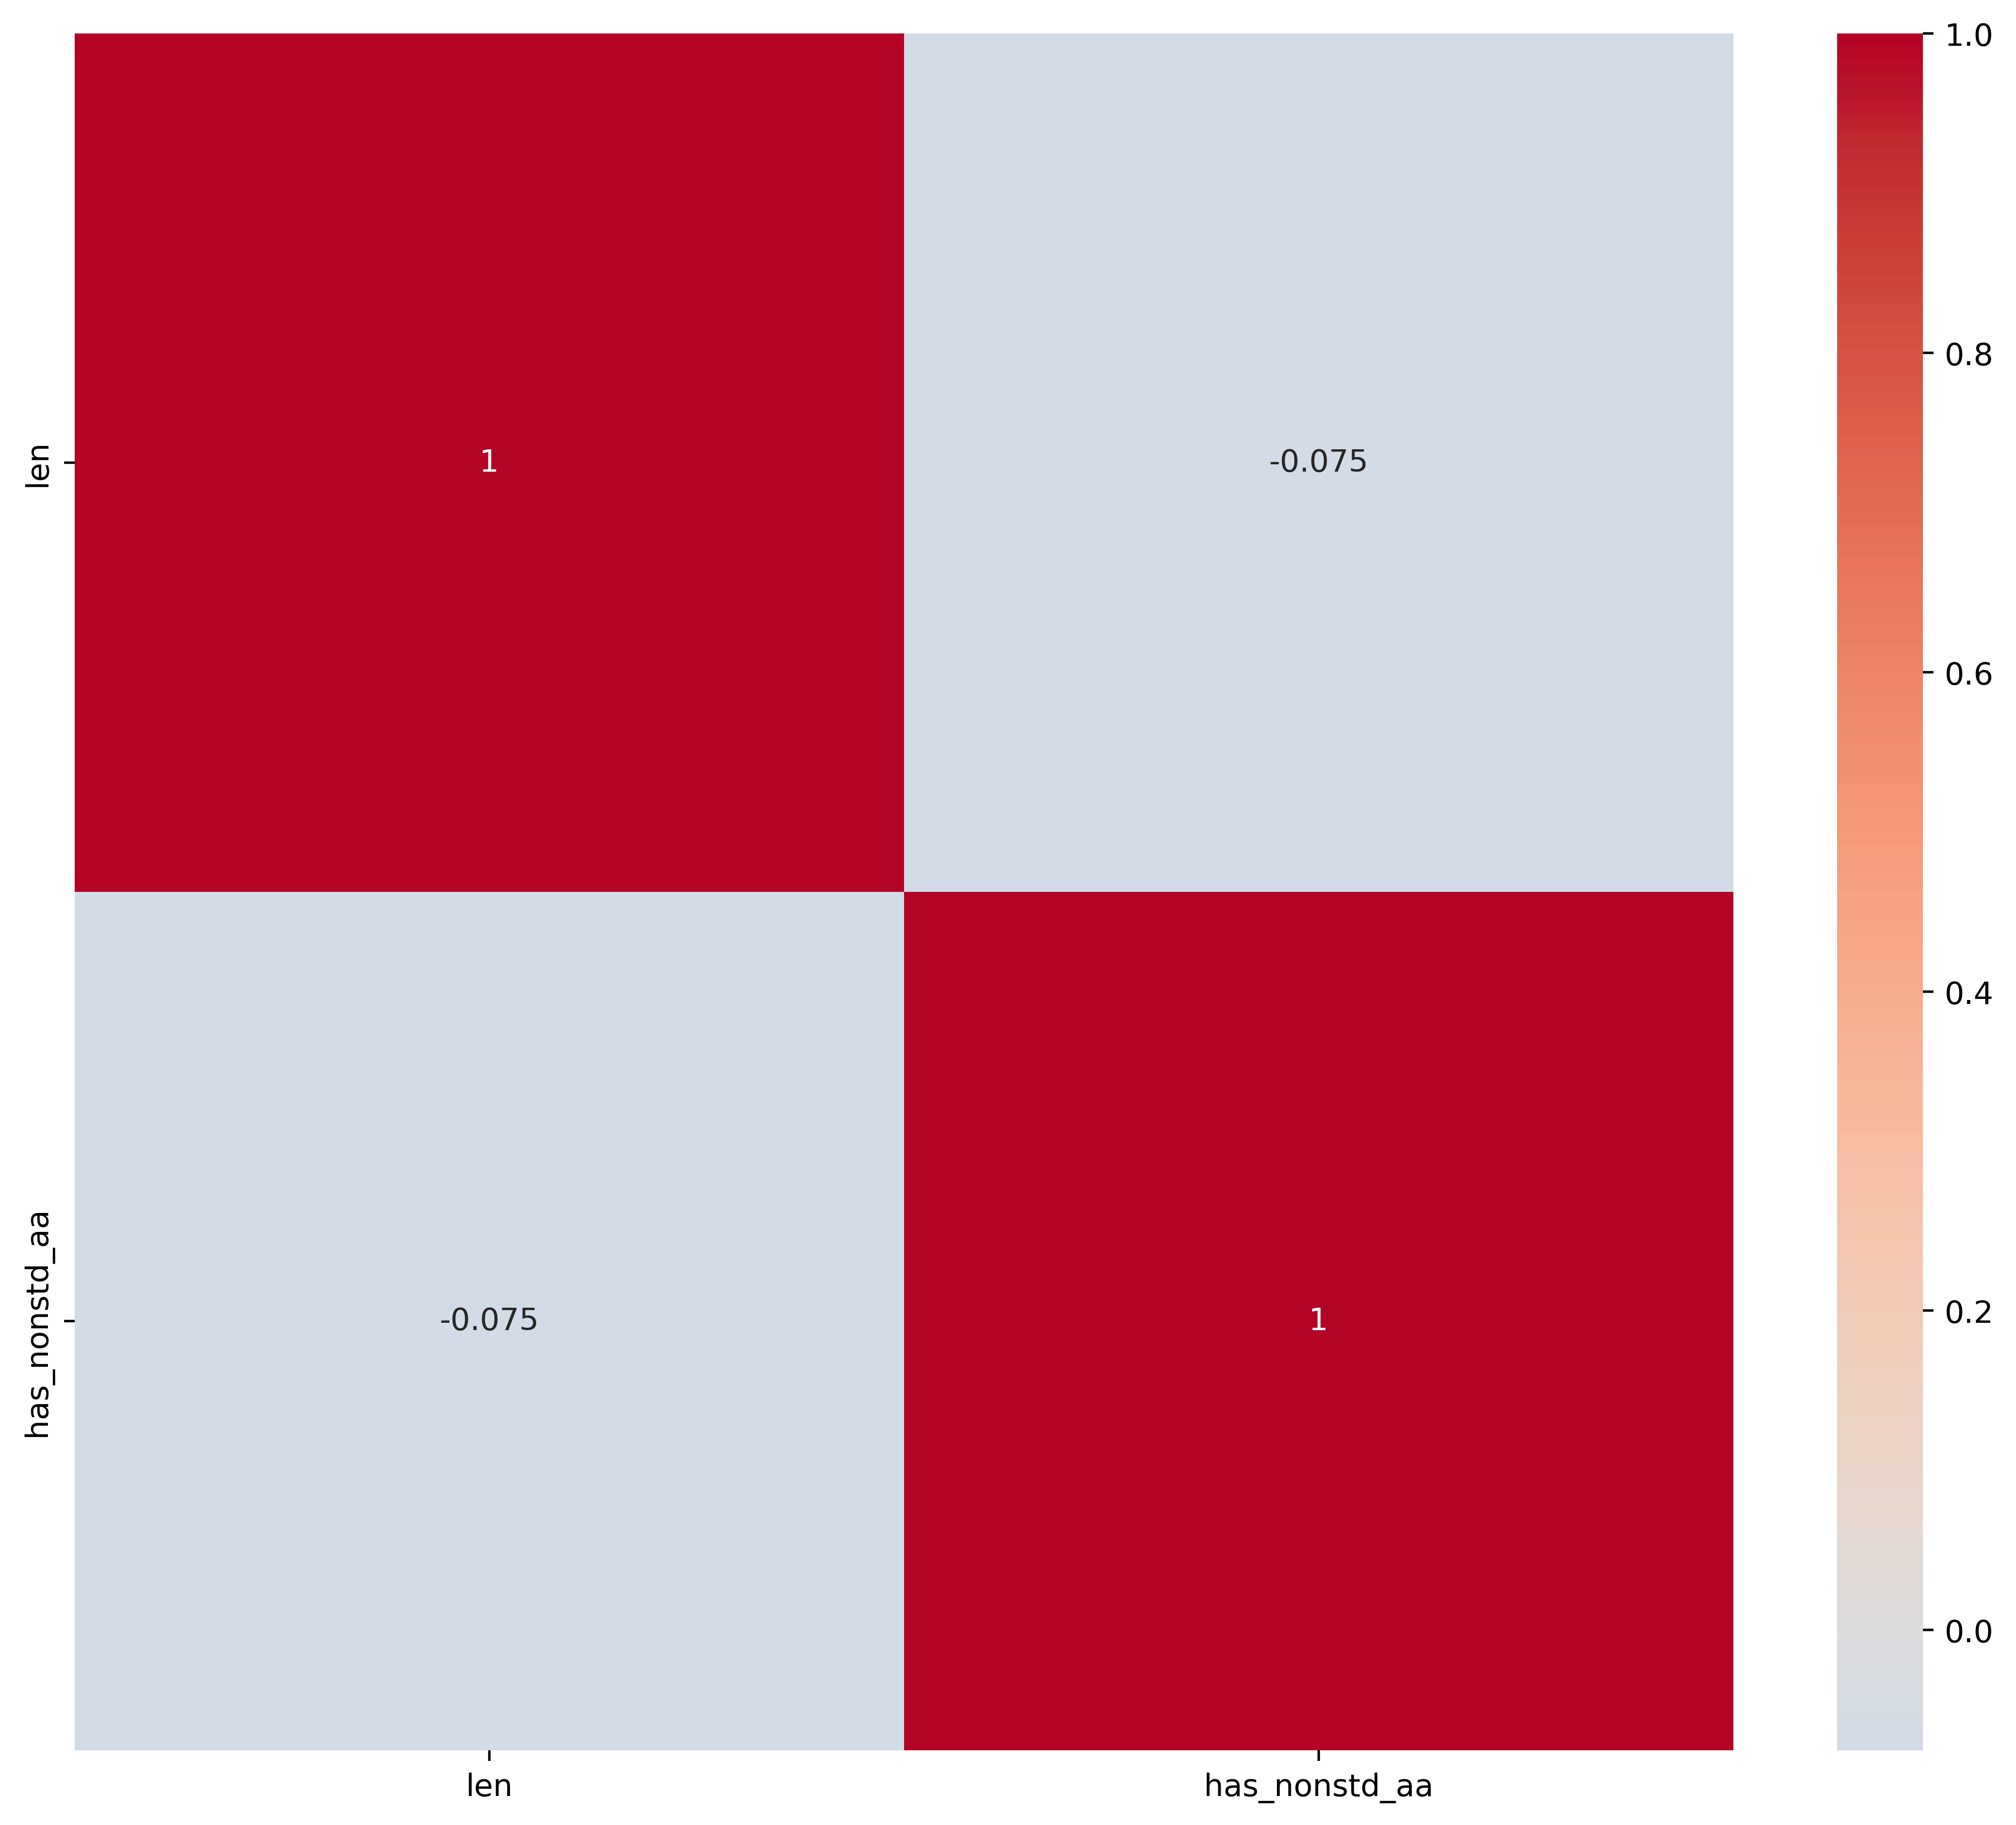

In [6]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=400)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);

plot distribution of protein length


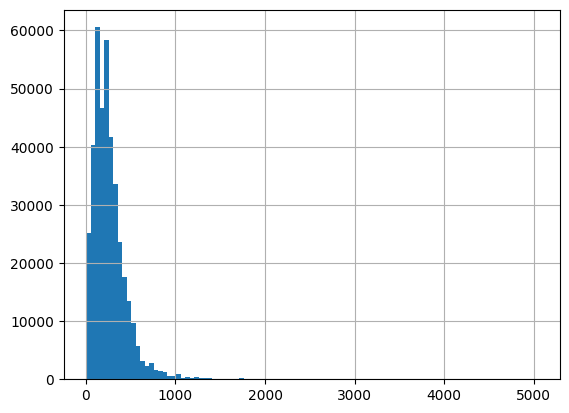

In [7]:
#plot distribution of protein length
df.len.hist(bins=100)
print('plot distribution of protein length')
maxlen_seq = 128
input_seqs, target_seqs = df[['seq', 'sst3']][
    (df.len <= maxlen_seq) & (~df.has_nonstd_aa)
].values.T

In [8]:
#Convert sequences into n-grams
def seq2ngrams(seqs, n=3):
    return [[seq[i:i+n] for i in range(len(seq)-n+1)] for seq in seqs]
input_grams = seq2ngrams(input_seqs)
input_grams[:10]

[['EDL'],
 ['KCK'],
 ['KAK'],
 ['KFK'],
 ['KAK'],
 ['KMK'],
 ['KHK'],
 ['KIK'],
 ['KAK'],
 ['KGK']]

In [9]:
#